In [1]:
%%time
import pandas as pd
import numpy as np
from lsynth import compute_upsilon, generate_syndata
import seaborn as sns

#model_path='./modelHRS72p05_train.gz'
#DATA="./HRSvar72_test.csv"
DATA='../datasets/gss_2018.csv'
model_path="../datasets/gss_2018.joblib"
orig_df=pd.read_csv(DATA,keep_default_na=False)

CPU times: user 3.28 s, sys: 665 ms, total: 3.94 s
Wall time: 2.57 s


# Generate synthetic data

In [2]:
%%time
# 1. Generate synthetic data with a chosen generator
df_lsm = generate_syndata(
    num=1000,
    model_path=model_path,
    gen_algorithm="LSM",
    n_workers=11,
)

Loading model from ../datasets/gss_2018.joblib ...
Generating 1000 rows via LSM (qsample).


qsample(LSM, threads=11): 100%|█████████████| 1000/1000 [10:53<00:00,  1.53it/s]


CPU times: user 10min 33s, sys: 45.8 s, total: 11min 18s
Wall time: 10min 57s


In [3]:
%%time
# 1. Generate synthetic data with a chosen generator
df_baseline = generate_syndata(
    num=1000,
    gen_algorithm="BASELINE",
    orig_df=orig_df,
    n_workers=11,
)

Generating 1000 rows via BASELINE (independent columns).
CPU times: user 686 ms, sys: 13.1 ms, total: 699 ms
Wall time: 692 ms


In [4]:
%%time
# 1. Generate synthetic data with a chosen generator
df_ctgan = generate_syndata(
    num=1000,
    gen_algorithm="CTGAN",
    orig_df=orig_df.sample(50),
    n_workers=11,
)

Generating 1000 rows via CTGAN.
CPU times: user 2h 7min 2s, sys: 5min 36s, total: 2h 12min 39s
Wall time: 23min 42s


# Compute Upsilon on synthetic dataframes

Loading model from ../datasets/gss_2018.joblib ...
Computing Upsilon on DataFrame with 1000 rows ...


average_fidelity(threads=11): 100%|█████████| 1000/1000 [05:00<00:00,  3.33it/s]


0.7966636460879927
CPU times: user 5min 2s, sys: 9.65 s, total: 5min 11s
Wall time: 5min 4s


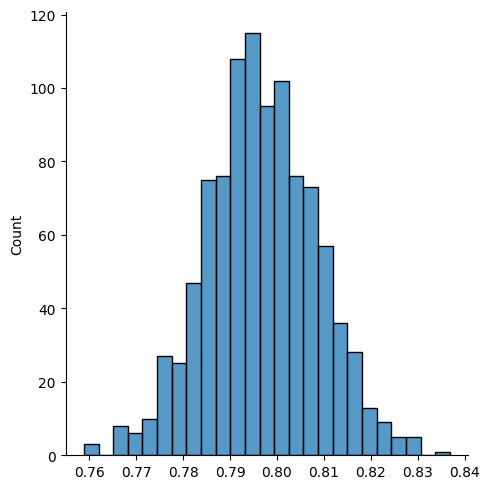

In [5]:
%%time
ups_lsm, _ = compute_upsilon(
    df_lsm,
    model_path=model_path,
    n_workers=11,
)
print(np.nanmean(ups_lsm))
sns.displot(ups_lsm)

In [6]:
%%time
df_baseline.columns=orig_df.columns

CPU times: user 38 µs, sys: 2 µs, total: 40 µs
Wall time: 44.8 µs


Loading model from ../datasets/gss_2018.joblib ...
Computing Upsilon on DataFrame with 1000 rows ...


average_fidelity(threads=11): 100%|█████████| 1000/1000 [05:07<00:00,  3.25it/s]


0.7475070695337579
CPU times: user 5min 8s, sys: 9.9 s, total: 5min 18s
Wall time: 5min 11s


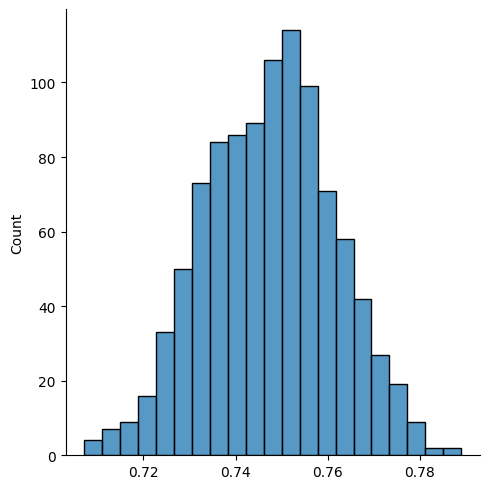

In [7]:
%%time
ups_baseline, _ = compute_upsilon(
    df_baseline,#.round(0).astype(int),
    model_path=model_path,
    n_workers=11,
)
print(np.nanmean(ups_baseline))
sns.displot(ups_baseline)

Loading model from ../datasets/gss_2018.joblib ...
Computing Upsilon on DataFrame with 1000 rows ...


average_fidelity(threads=11): 100%|█████████| 1000/1000 [05:15<00:00,  3.17it/s]


0.7538151466928259
CPU times: user 5min 16s, sys: 10.2 s, total: 5min 26s
Wall time: 5min 19s


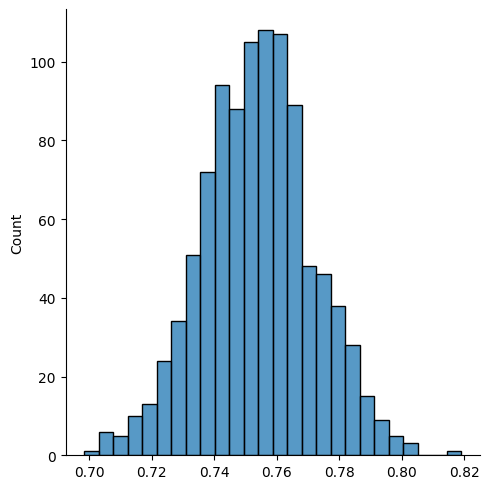

In [8]:
%%time
ups_ctgan, _ = compute_upsilon(
    df_ctgan,
    model_path=model_path,
    n_workers=11,
)
print(np.nanmean(ups_ctgan))
sns.displot(ups_ctgan)

Loading model from ../datasets/gss_2018.joblib ...
Computing Upsilon on DataFrame with 1000 rows ...


average_fidelity(threads=11): 100%|█████████| 1000/1000 [05:13<00:00,  3.19it/s]


0.8110618508926505
CPU times: user 5min 14s, sys: 10 s, total: 5min 24s
Wall time: 5min 17s


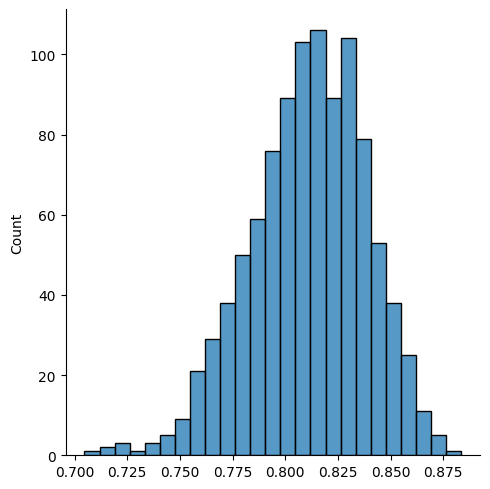

In [9]:
%%time
ups_perm, _ = compute_upsilon(
    orig_df.sample(1000),
    model_path=model_path,
    n_workers=11,
)
print(np.nanmean(ups_perm))
sns.displot(ups_perm)

CPU times: user 1.89 s, sys: 45 ms, total: 1.93 s
Wall time: 497 ms


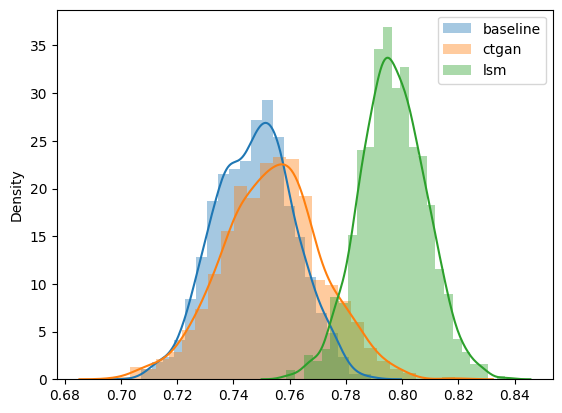

In [10]:
%%time
import pylab as plt
sns.distplot(ups_baseline,label='baseline')
sns.distplot(ups_ctgan,label='ctgan')
sns.distplot(ups_lsm,label='lsm')
plt.legend()

# How Novel Is The Generated Data

One-hot cosine similarity between categorical rows; off-diagonal block quantifies synthetic novelty versus near-copying.

In [20]:
%%time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

def row_similarity_blockplot(orig_df: pd.DataFrame,
                             syn_df: pd.DataFrame,
                             *,
                             metric: str = "cosine",
                             max_rows: int | None = 2000,
                             random_state: int = 123,
                             missing_token: str = "__MISSING__",
                             show_block_means: bool = True):
    if list(orig_df.columns) != list(syn_df.columns):
        raise ValueError("orig_df and syn_df must have identical columns in the same order.")

    o = orig_df.copy()
    s = syn_df.copy()
    if max_rows is not None:
        n = min(len(o), len(s), max_rows)
        o = o.sample(n=n, random_state=random_state).reset_index(drop=True)
        s = s.sample(n=n, random_state=random_state).reset_index(drop=True)

    def normalize(df: pd.DataFrame) -> pd.DataFrame:
        df = df.replace("", pd.NA)
        df = df.astype("string").fillna(missing_token)
        return df.astype(object)

    o = normalize(o)
    s = normalize(s)

    if metric == "match":
        X = np.vstack([o.to_numpy(), s.to_numpy()])
        G = (X[:, None, :] == X[None, :, :]).mean(axis=2).astype(np.float32)

    elif metric == "cosine":
        comb = pd.concat([o, s], axis=0, ignore_index=True)
        enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32)
        X = enc.fit_transform(comb)

        norms = np.linalg.norm(X, axis=1)
        norms[norms == 0] = 1.0
        G = (X @ X.T) / (norms[:, None] * norms[None, :])

    else:
        raise ValueError("metric must be 'cosine' or 'match'.")

    n = len(o)

    # Block means (RR, RS, SR, SS)
    rr = float(G[:n, :n].mean())
    rs = float(G[:n, n:].mean())
    sr = float(G[n:, :n].mean())
    ss = float(G[n:, n:].mean())
    block_means = np.array([[rr, rs],
                            [sr, ss]], dtype=float)

    # Plot full similarity + (optional) 2x2 block mean heatmap
    if show_block_means:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        im0 = axes[0].imshow(G, aspect="auto")
        axes[0].axhline(n - 0.5)
        axes[0].axvline(n - 0.5)
        axes[0].set_title(f"Row–row similarity ({metric})")
        fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

        BM = block_means#-block_means[0,1]
        print(BM)
        im1 = axes[1].imshow(BM, aspect="equal",vmin=.35,vmax=BM[0][0],cmap='Spectral_r')
        axes[1].set_xticks([0, 1], labels=["Real", "Synth"])
        axes[1].set_yticks([0, 1], labels=["Real", "Synth"])
        axes[1].set_title("2×2 block mean similarity")
        for (i, j), v in np.ndenumerate(BM):
            axes[1].text(j, i, f"{v:.3f}", ha="center", va="center")
        fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(7, 6))
        im = plt.imshow(G, aspect="auto")
        plt.axhline(n - 0.5)
        plt.axvline(n - 0.5)
        plt.title(f"Row–row similarity ({metric})")
        plt.colorbar(im, label="similarity")
        plt.tight_layout()
        plt.show()

    off_block = G[:n, n:]  # real x synth
    nn = off_block.max(axis=0)

    return {
        "n_rows_each": n,
        "nearest_real_similarity_mean": float(nn.mean()),
        "nearest_real_similarity_median": float(np.median(nn)),
        "nearest_real_similarity_p95": float(np.quantile(nn, 0.95)),
        "missing_token_used": missing_token,
        "block_means": {
            "real_real": rr,
            "real_synth": rs,
            "synth_real": sr,
            "synth_synth": ss,
        },
    }

CPU times: user 52 µs, sys: 0 ns, total: 52 µs
Wall time: 61 µs


## LSM synthetic data

[[0.48693627 0.33035079]
 [0.3303507  0.33324748]]


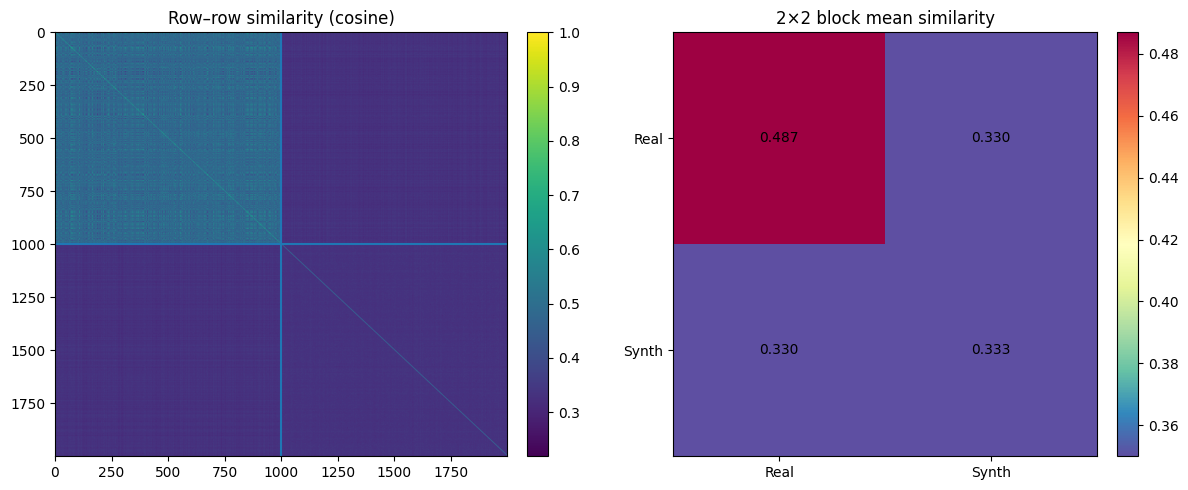

{'n_rows_each': 1000, 'nearest_real_similarity_mean': 0.3714255392551422, 'nearest_real_similarity_median': 0.37137335538864136, 'nearest_real_similarity_p95': 0.38974860310554504, 'missing_token_used': '__MISSING__', 'block_means': {'real_real': 0.4869362711906433, 'real_synth': 0.330350786447525, 'synth_real': 0.33035069704055786, 'synth_synth': 0.33324748277664185}}
CPU times: user 4.6 s, sys: 1.17 s, total: 5.77 s
Wall time: 3.37 s


In [21]:
%%time
statslsm = row_similarity_blockplot(orig_df, df_lsm, metric="cosine", max_rows=2000)
print(statslsm)

# CTGAN synthetic data

[[0.48693627 0.48273107]
 [0.48273087 0.5158453 ]]


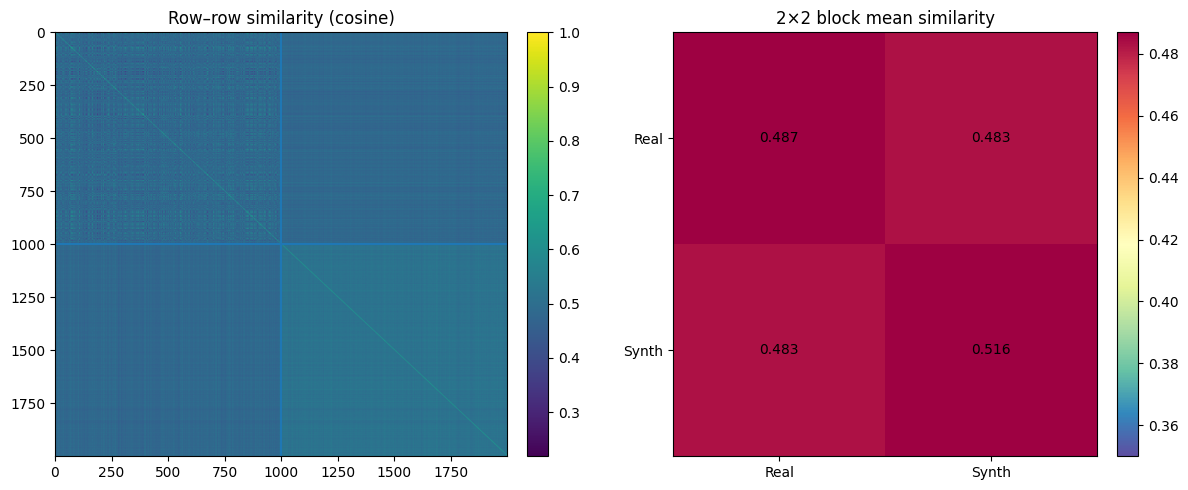

{'n_rows_each': 1000, 'nearest_real_similarity_mean': 0.5400145053863525, 'nearest_real_similarity_median': 0.5396519303321838, 'nearest_real_similarity_p95': 0.562862753868103, 'missing_token_used': '__MISSING__', 'block_means': {'real_real': 0.4869362711906433, 'real_synth': 0.48273107409477234, 'synth_real': 0.4827308654785156, 'synth_synth': 0.5158452987670898}}
CPU times: user 4.41 s, sys: 1.36 s, total: 5.78 s
Wall time: 2.94 s


In [22]:
%%time
statsctgan = row_similarity_blockplot(orig_df, df_ctgan, metric="cosine", max_rows=2000)
print(statsctgan)

# Baseline synthetic data

[[0.49874243 0.48700878]
 [0.48700878 0.49202311]]


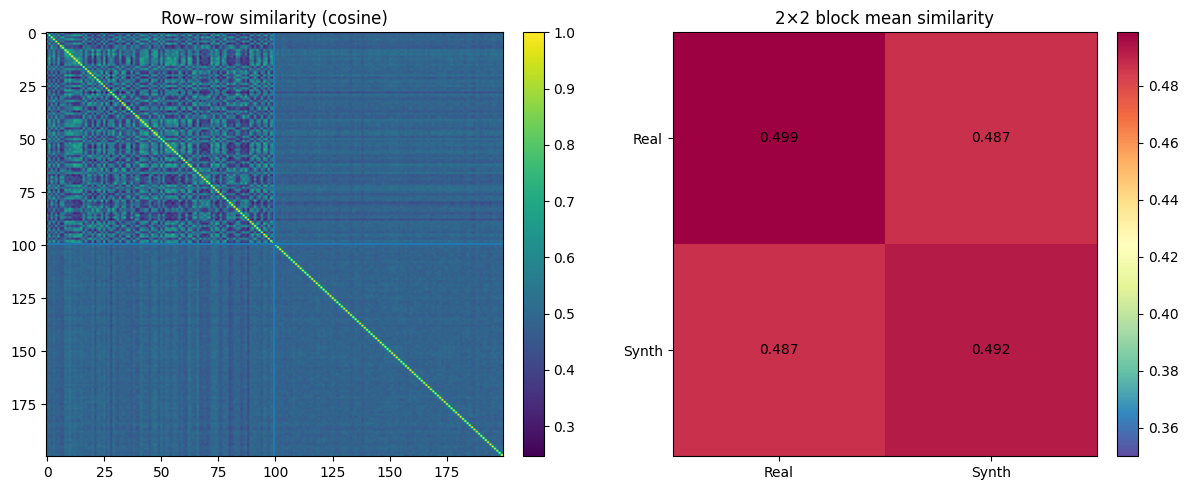

{'n_rows_each': 100, 'nearest_real_similarity_mean': 0.5329594612121582, 'nearest_real_similarity_median': 0.5328820943832397, 'nearest_real_similarity_p95': 0.5493714392185212, 'missing_token_used': '__MISSING__', 'block_means': {'real_real': 0.4987424314022064, 'real_synth': 0.4870087802410126, 'synth_real': 0.4870087802410126, 'synth_synth': 0.4920231103897095}}
CPU times: user 2.05 s, sys: 578 ms, total: 2.63 s
Wall time: 1.66 s


In [23]:
%%time
statsbaseline = row_similarity_blockplot(orig_df.head(100), df_baseline, metric="cosine", max_rows=2000)
print(statsbaseline)

# Permutated Original Data as "synthetic"

[[0.49874243 0.48502713]
 [0.48502713 0.48930508]]


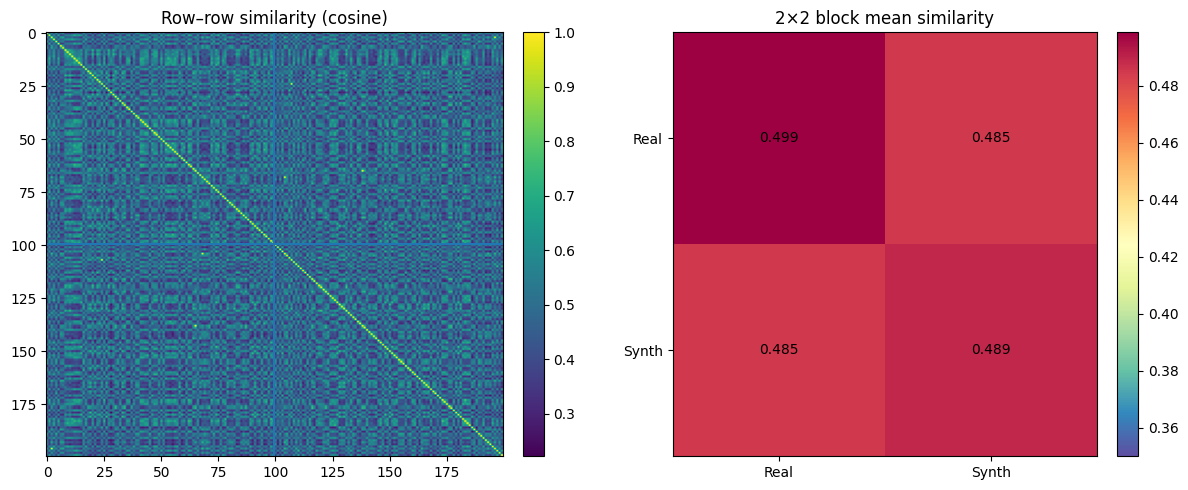

{'n_rows_each': 100, 'nearest_real_similarity_mean': 0.7221760749816895, 'nearest_real_similarity_median': 0.7132495641708374, 'nearest_real_similarity_p95': 0.7741780161857604, 'missing_token_used': '__MISSING__', 'block_means': {'real_real': 0.4987424314022064, 'real_synth': 0.48502713441848755, 'synth_real': 0.48502713441848755, 'synth_synth': 0.4893050789833069}}
CPU times: user 2.05 s, sys: 586 ms, total: 2.63 s
Wall time: 1.67 s


In [24]:
%%time
statsperm = row_similarity_blockplot(orig_df.head(100), orig_df.sample(100), metric="cosine", max_rows=2000)
print(statsperm)

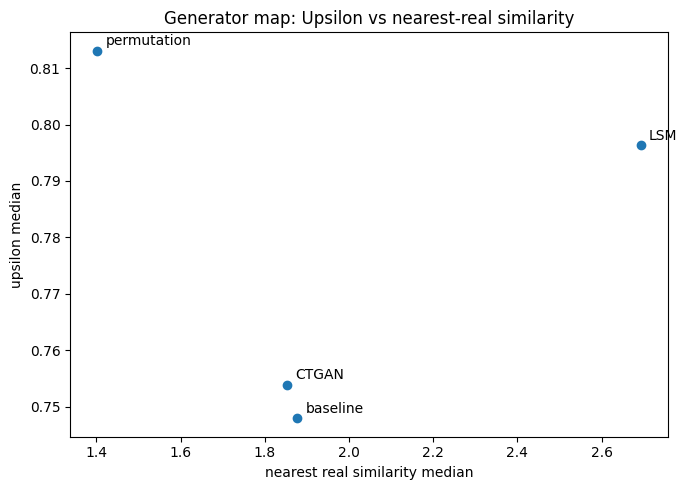

CPU times: user 329 ms, sys: 152 ms, total: 481 ms
Wall time: 220 ms


In [25]:
%%time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_generator_map(results, *, ups_key="upsilon_median", sim_key="nearest_real_similarity_median",
                       annotate=True, title="Generator map: Upsilon vs nearest-real similarity"):
    """
    results: dict like
      {
        "LSM": {"upsilon_median": 0.78, "nearest_real_similarity_median": 0.44},
        ...
      }

    x = nearest-real similarity (higher => closer to real rows; less movement)
    y = Upsilon (higher => better structural fidelity)
    """
    names = list(results.keys())
    x = np.array([results[n][sim_key] for n in names], dtype=float)
    y = np.array([results[n][ups_key] for n in names], dtype=float)

    plt.figure(figsize=(7, 5))
    plt.scatter(x, y)
    plt.xlabel(sim_key.replace("_", " "))
    plt.ylabel(ups_key.replace("_", " "))
    plt.title(title)

    if annotate:
        for n, xi, yi in zip(names, x, y):
            plt.annotate(n, (xi, yi), textcoords="offset points", xytext=(6, 4), ha="left")

    plt.tight_layout()
    plt.show()


# Example usage (fill in your Upsilon medians/means)
results = {
    "LSM":     {"upsilon_median": np.median(ups_lsm), "nearest_real_similarity_median": 1/statslsm['nearest_real_similarity_median']},
    "baseline":     {"upsilon_median": np.median(ups_baseline), "nearest_real_similarity_median": 1/statsbaseline['nearest_real_similarity_median']},
    "CTGAN":{"upsilon_median": np.median(ups_ctgan), "nearest_real_similarity_median": 1/statsctgan['nearest_real_similarity_median']},
    "permutation":{"upsilon_median": np.median(ups_perm), "nearest_real_similarity_median": 1/statsperm['nearest_real_similarity_median']},
}

plot_generator_map(results, ups_key="upsilon_median", sim_key="nearest_real_similarity_median")